# CropYield Predictor – Agricultural Intelligence & Analytics

## End-to-End Machine Learning Workflow

This notebook demonstrates the complete workflow for predicting agricultural crop yield using historical weather, rainfall, pesticide usage, and temperature data.

The workflow includes:

- Data Validation
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning Pipelines
- Model Training
- Hyperparameter Tuning
- Model Evaluation

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load dataset

df = pd.read_csv("../data/raw/yield_df.csv")

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## Dataset Inspection

In this section, we inspect the dataset structure, dimensions, data types, missing values, and descriptive statistics before performing any preprocessing.

In [4]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 28242
Columns : 8


In [5]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [6]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [7]:
missing = df.isnull().sum()

missing

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

In [10]:
df.sample(10, random_state=42)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
25564,25564,Spain,"Rice, paddy",2008,69220,636.0,40719.00,17.21
18113,18113,Madagascar,Wheat,1996,20000,1513.0,152.01,19.71
25607,25607,Spain,Sorghum,2010,51206,636.0,39043.00,16.51
6815,6815,Colombia,Potatoes,2007,166986,3240.0,82439.06,27.45
18144,18144,Madagascar,Sweet potatoes,2000,56319,1513.0,130.46,19.65
12680,12680,India,"Rice, paddy",2002,26163,1083.0,42482.56,26.66
3474,3474,Brazil,"Rice, paddy",1999,30708,1761.0,127585.00,25.88
22381,22381,Pakistan,Sweet potatoes,2000,109771,494.0,27885.00,27.12
20656,20656,Morocco,Potatoes,2004,241650,346.0,15064.00,18.21
23170,23170,Papua New Guinea,Sweet potatoes,1992,47500,3142.0,121.00,25.30


In [11]:
# Data validation report 
validation = pd.DataFrame({
    "Data Type":df.dtypes,
    "Missing Values":df.isnull().sum(),
    "Unique Values":df.nunique()
})

validation

,Data Type,Missing Values,Unique Values
Unnamed: 0,int64,0,28242
Area,object,0,101
Item,object,0,10
Year,int64,0,23
hg/ha_yield,int64,0,11514
average_rain_fall_mm_per_year,float64,0,100
pesticides_tonnes,float64,0,1673
avg_temp,float64,0,1831


In [12]:
#- Export Data Dictionary

data_dictionary = pd.DataFrame({
    "Column Name":df.columns,
    "Data Type":df.dtypes.values
})

data_dictionary.to_csv(
    "../data/processed/data_dictionary.csv",
    index=False
)

data_dictionary

,Column Name,Data Type
0,Unnamed: 0,int64
1,Area,object
2,Item,object
3,Year,int64
4,hg/ha_yield,int64
5,average_rain_fall_mm_per_year,float64
6,pesticides_tonnes,float64
7,avg_temp,float64


# Data Cleaning

### Objective
Handle missing values, remove unnecessary columns, detect duplicate records, identify outliers, correct data types, and export the cleaned dataset.

In [13]:
df_clean = df.copy()

In [14]:
#Remove Unnecessary Column

df_clean.drop(columns=["Unnamed: 0"], inplace=True)

df_clean.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [15]:
#Missing Values
df_clean.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

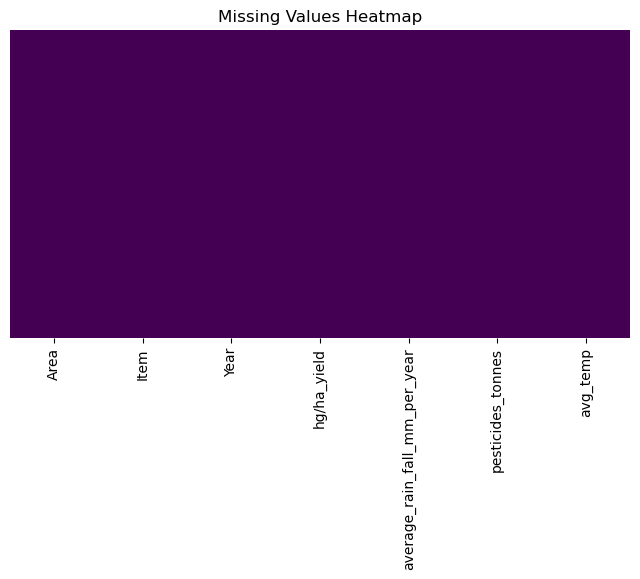

In [16]:
#Missing Value Heatmap
plt.figure(figsize=(8,4))

sns.heatmap(
    df_clean.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

Observation:
The dataset contains no missing values. The missing value heatmap confirms that all features are complete, so no imputation techniques were required.

In [17]:
# Remove duplicate rows

print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)

print("After :", df_clean.shape)

Before: (28242, 7)
After : (25932, 7)


In [18]:
df_clean.duplicated().sum()

np.int64(0)

## Outlier Detection

In [19]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

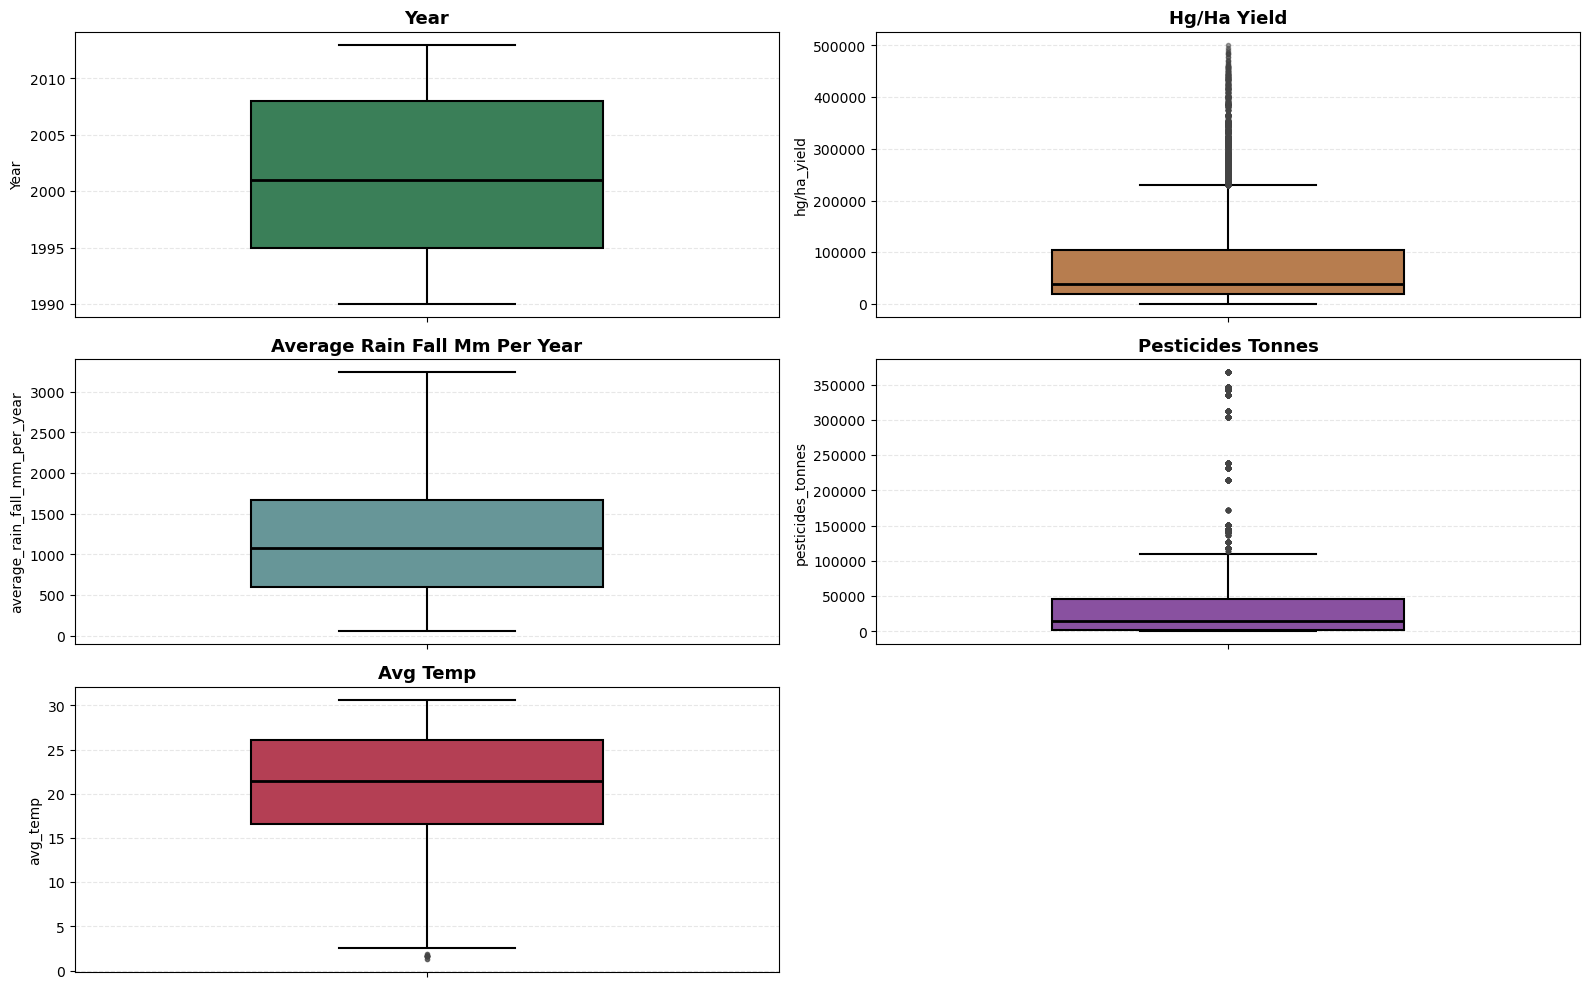

In [20]:
# boxplot 

colors = [
    "#2E8B57",  # Year
    "#C97B3D",  # Yield
    "#5F9EA0",  # Rainfall
    "#8E44AD",  # Pesticides
    "#C72C48"   # Temperature
]

plt.figure(figsize=(16, 10))

for i, column in enumerate(numerical_columns):

    plt.subplot(3, 2, i + 1)

    sns.boxplot(
        y=df_clean[column],
        color=colors[i],
        width=0.5,
        linewidth=1.5,
        boxprops=dict(edgecolor="black"),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="#444444",
            markeredgecolor="#444444",
            alpha=0.5
        )
    )

    plt.title(column.replace("_", " ").title(),
              fontsize=13,
              fontweight="bold")

    plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# IQR
for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]

    print(f"{column}: {len(outliers)} outliers")

Year: 0 outliers
hg/ha_yield: 1918 outliers
average_rain_fall_mm_per_year: 0 outliers
pesticides_tonnes: 1262 outliers
avg_temp: 16 outliers


### Observation

- No outliers were detected in Year, Rainfall and Average Temperature.
- Outliers were detected in Crop Yield and Pesticide Usage.
- These values were retained because they represent realistic agricultural variations rather than data entry errors.
- Tree-based machine learning models used later in the project are robust to such observations.

In [22]:
# Export
df_clean.to_csv(
    "../data/processed/cleaned_crop_yield.csv",
    index=False
)

#  Exploratory Data Analysis (EDA Part 1)

## Objective

- Understand feature distributions.
- Analyze numerical feature statistics.
- Identify relationships among numerical variables.
- Find the strongest correlations with Crop Yield.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_crop_yield.csv")

df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [24]:
#Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,25932.0,2001.556455,7.055924,1990.00,1995.00,2001.00,2008.00,2013.00
hg/ha_yield,25932.0,76978.132925,84647.605552,50.00,19996.00,39530.00,104168.00,501412.00
average_rain_fall_mm_per_year,25932.0,1146.836688,717.391098,51.00,593.00,1083.00,1668.00,3240.00
pesticides_tonnes,25932.0,34782.573241,57228.568244,0.04,1597.00,15373.00,45620.00,367778.00
avg_temp,25932.0,20.422251,6.439402,1.30,16.58,21.42,26.06,30.65


### Observation

- Numerical features show varying scales.
- Crop Yield has a wide distribution.
- Rainfall and pesticide usage vary significantly across observations.

# Univariate Distribution

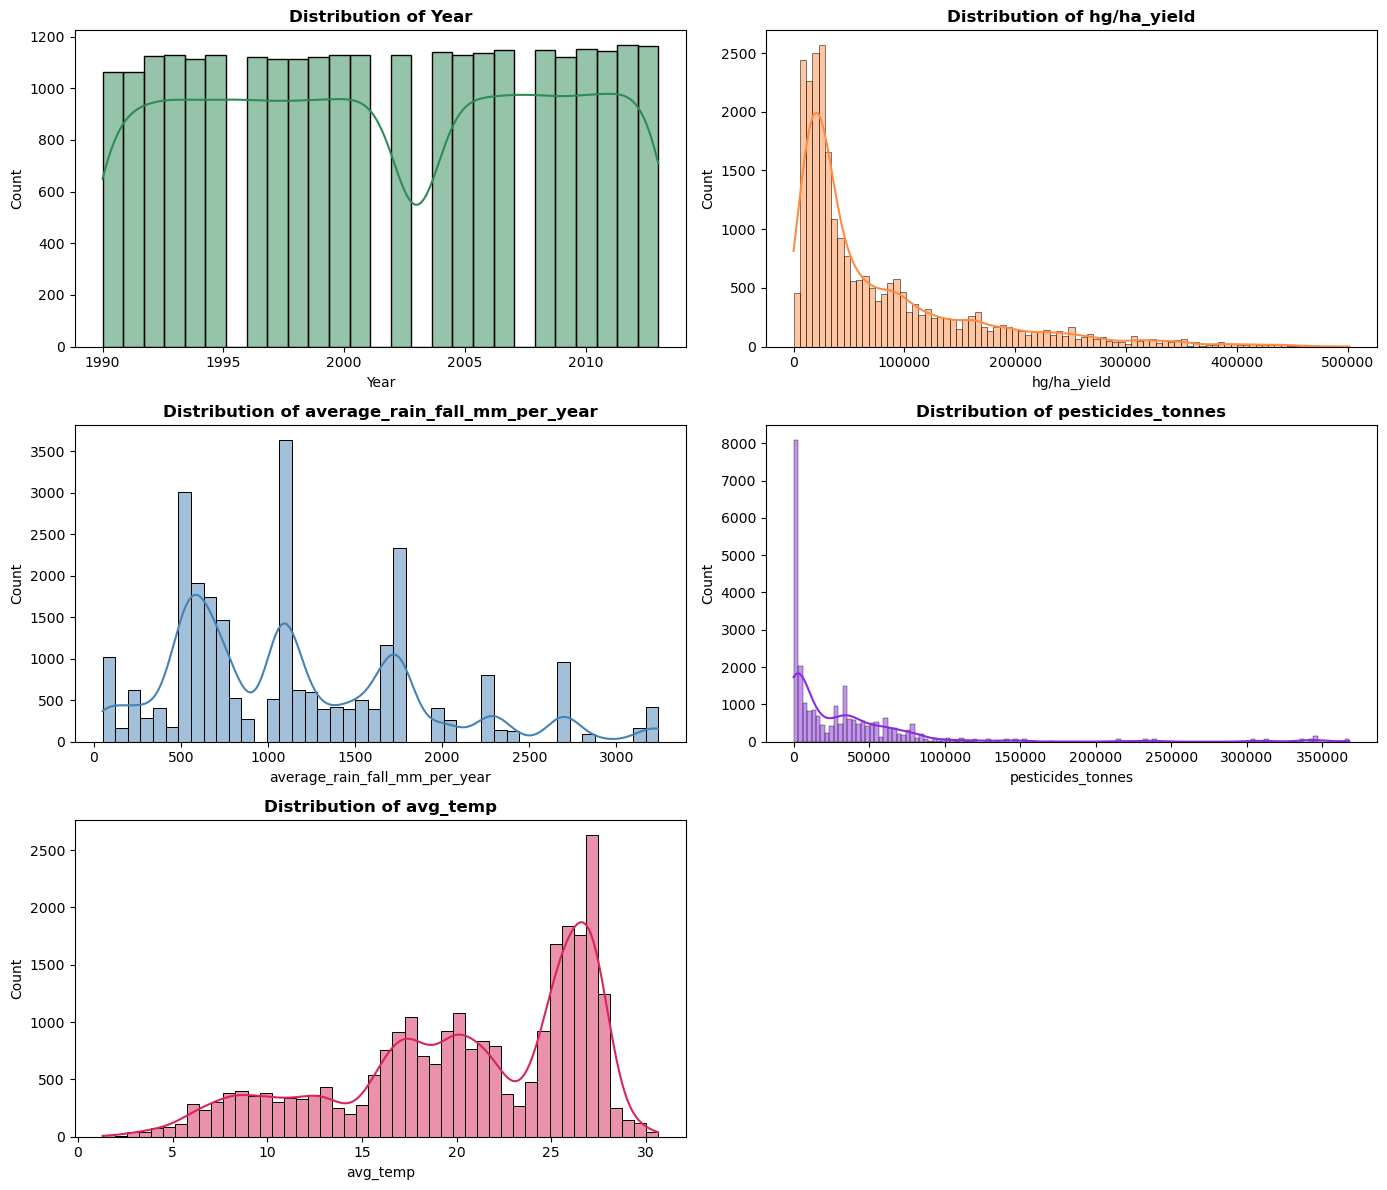

In [25]:
num_cols = [
    "Year",
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

colors = ["#2E8B57","#FF8C42","#4682B4","#8A2BE2","#D7265A"]

fig, axes = plt.subplots(3,2,figsize=(14,12))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.histplot(
        df[col],
        kde=True,
        color=colors[i],
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}",
                      fontsize=12,
                      fontweight="bold")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Observation

- Crop Yield (hg/ha_yield) is highly right-skewed with several large values.
- Pesticide usage also shows a positively skewed distribution.
- Average rainfall has multiple peaks, indicating different climatic regions.
- Average temperature follows a multimodal distribution.
- Year is almost uniformly distributed between 1990 and 2013.

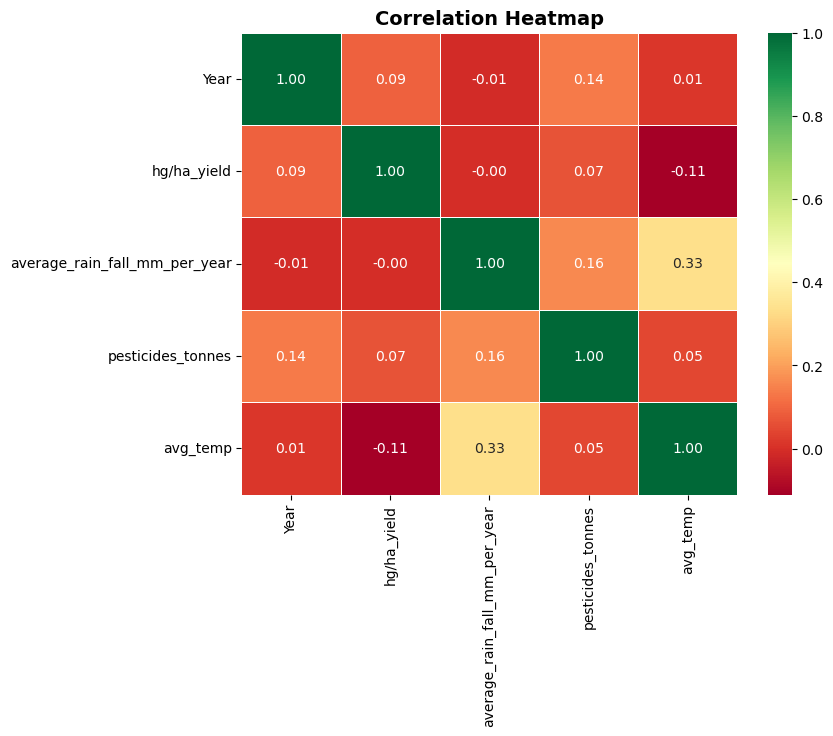

In [26]:
#CORRELATION  HEATMAP
plt.figure(figsize=(8,6))

corr=df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",fontsize=14,fontweight="bold")

plt.show()

In [27]:
plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Observation

- Crop Yield has a weak positive correlation with Year (0.09).
- Crop Yield has a weak positive correlation with Pesticide Usage (0.07).
- Crop Yield has almost no linear relationship with Rainfall.
- Crop Yield has a weak negative correlation with Average Temperature (-0.11).
- No pair of variables shows a very high correlation, indicating low multicollinearity.

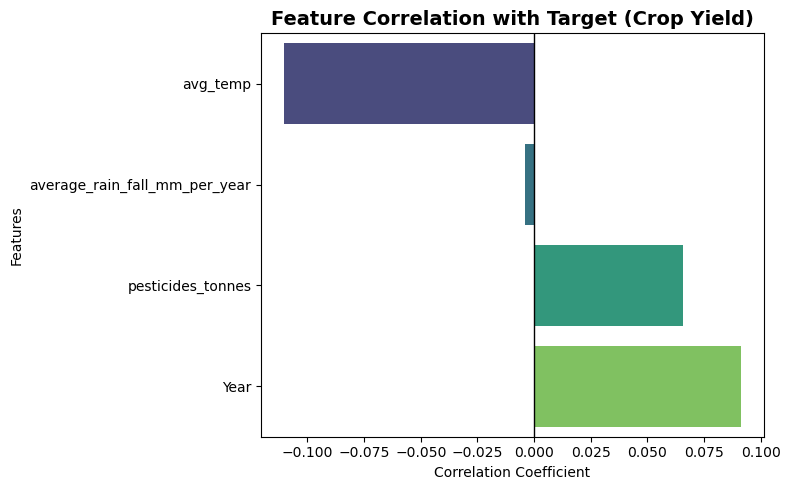

In [28]:
#Top Feature Correlation with Target
target_corr = (
    df.corr(numeric_only=True)["hg/ha_yield"]
      .drop("hg/ha_yield")
      .sort_values()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    hue=target_corr.index,
    palette="viridis",
    legend=False
)

plt.axvline(0,color="black",linewidth=1)

plt.title(
    "Feature Correlation with Target (Crop Yield)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")

plt.ylabel("Features")

plt.tight_layout()

plt.show()

### Observation

- Year shows the highest positive correlation with Crop Yield (0.09).
- Pesticide usage has a weak positive correlation (0.07).
- Rainfall has almost no linear relationship with Crop Yield.
- Average Temperature has a weak negative correlation (-0.11).
- Overall, no feature exhibits a strong linear correlation with the target variable.

### Note

The dataset contains only four numerical predictor variables apart from the target variable (Crop Yield). Therefore, all available numerical features were included in the correlation analysis instead of Top-10 features.

In [29]:
plt.savefig(
    "../images/top_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#  Exploratory Data Analysis (EDA Part 2)

## Objective

- Perform bivariate analysis.
- Analyze Crop Yield across different regions.
- Study the relationship between rainfall and crop yield.
- Explore interactions among numerical features using pair plots.

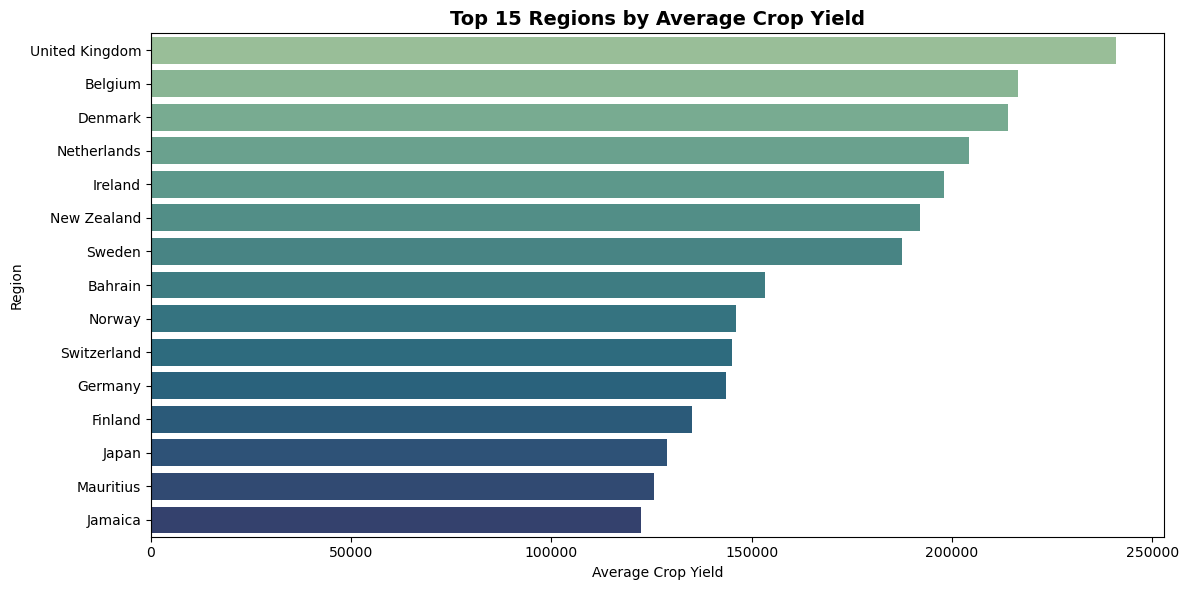

In [30]:
#Crop Yield by Region (Top 15)
top_regions = (
    df.groupby("Area")["hg/ha_yield"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    hue=top_regions.index,
    palette="crest",
    legend=False
)

plt.title(
    "Top 15 Regions by Average Crop Yield",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Crop Yield")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "../images/crop_yield_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Certain regions consistently produce higher average crop yields.
- This indicates geographical differences in agricultural productivity.

# Rainfall vs Crop Yield

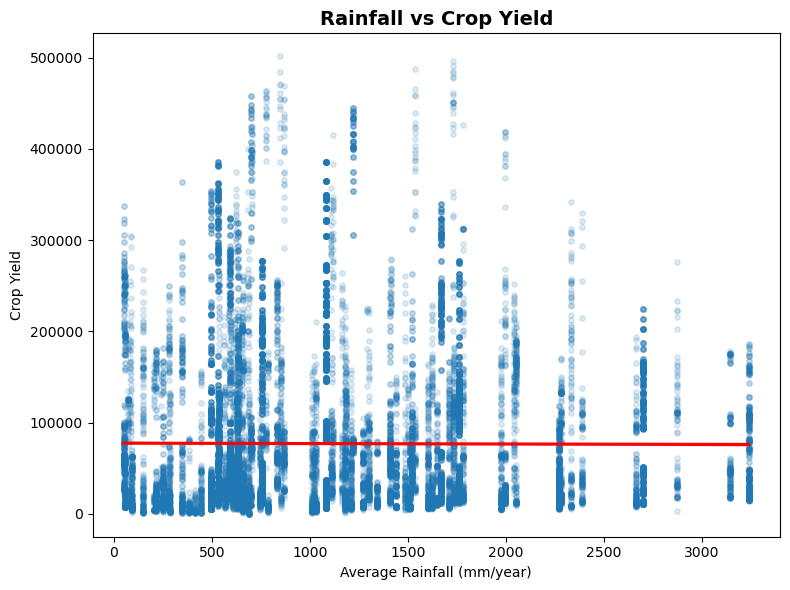

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="average_rain_fall_mm_per_year",
    y="hg/ha_yield",
    scatter_kws={
    "alpha":0.15,
    "s":15
},
    line_kws={"color":"red"}
)

plt.title(
    "Rainfall vs Crop Yield",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Rainfall (mm/year)")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../images/rainfall_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Crop yield exhibits a highly scattered distribution across rainfall levels.
- The regression line is nearly flat, indicating a very weak linear relationship.
- This suggests that rainfall alone is not a strong predictor of crop yield.

# Temperature vs Crop Yield

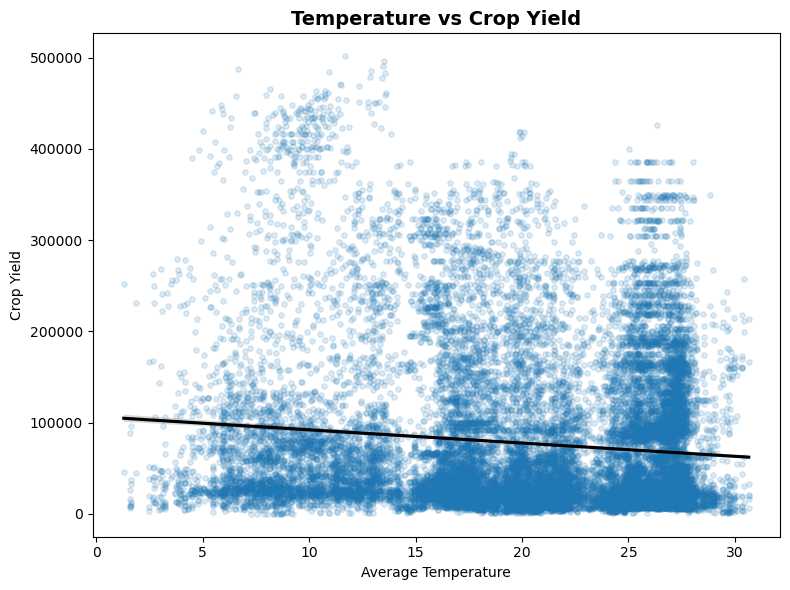

In [32]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="avg_temp",
    y="hg/ha_yield",
    scatter_kws={
    "alpha":0.15,
    "s":15
},
    line_kws={"color":"black"}
)

plt.title(
    "Temperature vs Crop Yield",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Temperature")
plt.ylabel("Crop Yield")

plt.tight_layout()

plt.savefig(
    "../images/temperature_vs_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation


- A weak negative relationship is observed between temperature and crop yield.
- Crop yield is influenced by multiple agricultural factors rather than temperature alone.
- The wide dispersion indicates high variability across crops and regions.

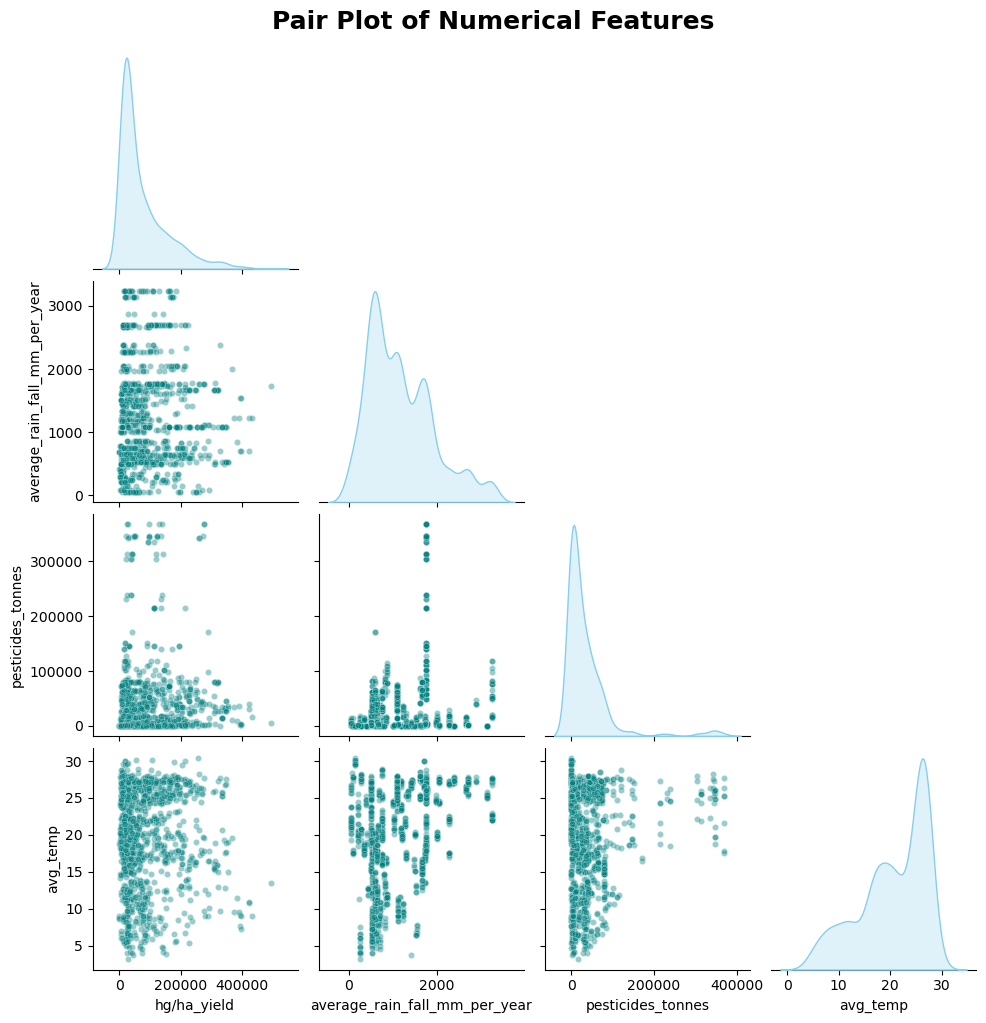

In [33]:
# Pair Plot (Using Sample Data)

sample_df = df_clean.sample(1500, random_state=42)

pair_columns = [
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

sns.pairplot(
    sample_df[pair_columns],
    diag_kind="kde",
    corner=True,
    plot_kws={
        "alpha":0.4,
        "s":20,
        "color":"teal"
    },
    diag_kws={
        "fill":True,
        "color":"skyblue"
    }
)

plt.suptitle(
    "Pair Plot of Numerical Features",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.savefig(
    "../images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Pair plot shows weak pairwise linear relationships among most numerical variables.
- Crop yield exhibits high variability across rainfall, pesticide usage, and temperature.
- Rainfall and pesticide usage display slight positive associations, while temperature shows a weak negative trend with crop yield.
- The absence of strong linear relationships suggests that machine learning models can capture complex, non-linear interactions better than simple linear methods.

## Summary

- Performed bivariate analysis of crop yield and environmental variables.
- Identified top-performing regions based on average crop yield.
- Explored rainfall and temperature relationships with crop yield.
- Generated pair plots to understand interactions among numerical features.

# Feature Engineering

## Objective

The objective of this phase is to engineer meaningful features that can improve machine learning model performance.

The internship brief recommends creating features such as NPK ratios, rainfall categories, humidity index, and Growing Degree Days (GDD).

However, the selected Crop Yield dataset does not contain Nitrogen (N), Phosphorus (P), Potassium (K), or Humidity variables. Therefore, equivalent domain-relevant features are engineered using the available rainfall, temperature, pesticide usage, and crop yield variables.

In [34]:
# Create a copy of the cleaned dataset for feature engineering

df_features = df_clean.copy()

df_features.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


### Observation

A separate copy of the cleaned dataset was created to preserve the original cleaned data while performing feature engineering.

In [35]:
# Display available columns

df_features.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

### Observation

The dataset contains rainfall, temperature, pesticide usage, and crop yield information.

Since Nitrogen (N), Phosphorus (P), Potassium (K), and Humidity are unavailable, equivalent agricultural features will be engineered from the existing variables.

In [36]:
# Create rainfall categories

bins = [0,500,1000,2000,float("inf")]

labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

df_features["Rainfall_Category"] = pd.cut(
    df_features["average_rain_fall_mm_per_year"],
    bins=bins,
    labels=labels
)

df_features[
    [
        "average_rain_fall_mm_per_year",
        "Rainfall_Category"
    ]
].head()

,average_rain_fall_mm_per_year,Rainfall_Category
0,1485.0,High
1,1485.0,High
2,1485.0,High
3,1485.0,High
4,1485.0,High


### Observation

Rainfall has been grouped into four agricultural categories.

Categorical rainfall information can help machine learning models capture rainfall intensity patterns more effectively than raw numerical values alone.

In [37]:
# Base temperature for crop growth

BASE_TEMP = 10

df_features["Growing_Degree_Days"] = (
    df_features["avg_temp"] - BASE_TEMP
).clip(lower=0)

df_features[
    [
        "avg_temp",
        "Growing_Degree_Days"
    ]
].head()

,avg_temp,Growing_Degree_Days
0,16.37,6.37
1,16.37,6.37
2,16.37,6.37
3,16.37,6.37
4,16.37,6.37


### Observation

Growing Degree Days (GDD) estimate accumulated heat available for crop growth.

Negative values were clipped to zero because crop development does not occur below the base temperature.

## Temperature Category

Temperature values are grouped into agricultural categories.

Categorizing temperature helps machine learning models identify climatic zones that may influence crop productivity more effectively than raw numerical values.

In [38]:
# Create temperature categories

temp_bins = [0, 10, 20, 25, float("inf")]

temp_labels = [
    "Cold",
    "Moderate",
    "Warm",
    "Hot"
]

df_features["Temperature_Category"] = pd.cut(
    df_features["avg_temp"],
    bins=temp_bins,
    labels=temp_labels
)

df_features[
    [
        "avg_temp",
        "Temperature_Category"
    ]
].head()

,avg_temp,Temperature_Category
0,16.37,Moderate
1,16.37,Moderate
2,16.37,Moderate
3,16.37,Moderate
4,16.37,Moderate


### Observation

Average temperature values were grouped into four agricultural climate categories.

This transformation enables the model to capture climatic patterns that may not be evident from continuous temperature values alone.

## Pesticide Usage Category

Pesticide usage is converted into categorical levels based on its distribution.

This feature may help identify differences in crop yield across varying pesticide application levels.

In [39]:
# Create pesticide usage categories using quartiles

df_features["Pesticide_Category"] = pd.qcut(
    df_features["pesticides_tonnes"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df_features[
    [
        "pesticides_tonnes",
        "Pesticide_Category"
    ]
].head()

,pesticides_tonnes,Pesticide_Category
0,121.0,Low
1,121.0,Low
2,121.0,Low
3,121.0,Low
4,121.0,Low


### Observation

Pesticide usage was divided into four equal-frequency categories using quartiles.

This reduces the impact of highly skewed numerical values while preserving meaningful usage patterns.

## Rainfall per Temperature Ratio

A new feature is created by dividing annual rainfall by average temperature.

This ratio captures the combined effect of rainfall availability and climatic conditions, providing additional information beyond individual variables.

In [40]:
# Create Rainfall per Temperature Ratio

df_features["Rainfall_Temp_Ratio"] = (
    df_features["average_rain_fall_mm_per_year"] /
    df_features["avg_temp"]
)

df_features[
    [
        "average_rain_fall_mm_per_year",
        "avg_temp",
        "Rainfall_Temp_Ratio"
    ]
].head()

,average_rain_fall_mm_per_year,avg_temp,Rainfall_Temp_Ratio
0,1485.0,16.37,90.714722
1,1485.0,16.37,90.714722
2,1485.0,16.37,90.714722
3,1485.0,16.37,90.714722
4,1485.0,16.37,90.714722


### Observation

The Rainfall–Temperature Ratio represents the amount of annual rainfall available per unit of average temperature.

This engineered feature may help machine learning models capture interactions between rainfall and temperature that influence crop productivity.

## Yield per Unit of Pesticide

This feature estimates crop yield produced for each unit of pesticide applied.

Adding 1 to the denominator prevents division by zero.

In [41]:
# Create Yield per Unit of Pesticide

df_features["Yield_per_Pesticide"] = (
    df_features["hg/ha_yield"] /
    (df_features["pesticides_tonnes"] + 1)
)

df_features[
    [
        "hg/ha_yield",
        "pesticides_tonnes",
        "Yield_per_Pesticide"
    ]
].head()

,hg/ha_yield,pesticides_tonnes,Yield_per_Pesticide
0,36613,121.0,300.106557
1,66667,121.0,546.450820
2,23333,121.0,191.254098
3,12500,121.0,102.459016
4,7000,121.0,57.377049


### Observation

Yield per Pesticide estimates agricultural productivity relative to pesticide usage.

This feature may help identify efficient pesticide utilization patterns and improve predictive performance.

In [42]:
# Export feature engineered dataset

df_features.to_csv(
    "../data/processed/feature_engineered_crop_yield.csv",
    index=False
)

print("Feature engineered dataset exported successfully.")

Feature engineered dataset exported successfully.


# Feature Engineering Summary

## Engineered Features

- Rainfall_Category
- Growing_Degree_Days
- Temperature_Category
- Pesticide_Category
- Rainfall_Temp_Ratio
- Yield_per_Pesticide

## Features Not Created

The internship brief suggests engineering NPK ratio features and a Humidity Index.

These features were not created because the selected Crop Yield dataset does not contain Nitrogen (N), Phosphorus (P), Potassium (K), or Humidity variables.

Instead, meaningful domain-specific features were engineered using the available rainfall, temperature, pesticide usage, and crop yield variables.

In [43]:
df_features.info()

df_features.head()

<class 'pandas.core.frame.DataFrame'>
Index: 25932 entries, 0 to 28241
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Area                           25932 non-null  object  
 1   Item                           25932 non-null  object  
 2   Year                           25932 non-null  int64   
 3   hg/ha_yield                    25932 non-null  int64   
 4   average_rain_fall_mm_per_year  25932 non-null  float64 
 5   pesticides_tonnes              25932 non-null  float64 
 6   avg_temp                       25932 non-null  float64 
 7   Rainfall_Category              25932 non-null  category
 8   Growing_Degree_Days            25932 non-null  float64 
 9   Temperature_Category           25932 non-null  category
 10  Pesticide_Category             25932 non-null  category
 11  Rainfall_Temp_Ratio            25932 non-null  float64 
 12  Yield_per_Pesticide            25932 

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Rainfall_Category,Growing_Degree_Days,Temperature_Category,Pesticide_Category,Rainfall_Temp_Ratio,Yield_per_Pesticide
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,300.106557
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,546.450820
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,191.254098
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,102.459016
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,57.377049


# ML Pipeline
## Objective

The objective of this phase is to prepare the feature-engineered dataset for machine learning.

This includes splitting the data into training and testing sets, creating a preprocessing pipeline using ColumnTransformer, and training baseline regression models for crop yield prediction.

The internship brief requires the use of a Scikit-Learn Pipeline to ensure a reproducible workflow and prevent data leakage.

In [44]:
# Machine Learning Libraries

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import RandomForestRegressor

In [45]:
# Load feature engineered dataset

df_ml = pd.read_csv(
    "../data/processed/feature_engineered_crop_yield.csv"
)

df_ml.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Rainfall_Category,Growing_Degree_Days,Temperature_Category,Pesticide_Category,Rainfall_Temp_Ratio,Yield_per_Pesticide
0,Albania,Maize,1990,36613,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,300.106557
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,546.450820
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,191.254098
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,102.459016
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37,High,6.37,Moderate,Low,90.714722,57.377049


The feature-engineered dataset was successfully loaded into the notebook. It contains both the original variables and the newly engineered features created during the previous phase. This dataset will be used for building machine learning pipelines and training predictive models.

In [46]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
 7   Rainfall_Category              25932 non-null  object 
 8   Growing_Degree_Days            25932 non-null  float64
 9   Temperature_Category           25932 non-null  object 
 10  Pesticide_Category             25932 non-null  object 
 11  Rainfall_Temp_Ratio            25932 non-null  float64
 12  Yield_per_Pesticide            25932 non-null 

The dataset contains numerical and categorical variables with appropriate data types. No missing values are present, indicating that the dataset is ready for preprocessing and machine learning model development.

In [47]:
# Target Variable

target = "hg/ha_yield"

In [48]:
#Define Features

X = df_ml.drop(columns=[target])

y = df_ml[target]

The target variable was defined as Crop Yield (hg/ha_yield), while all remaining variables were selected as input features. Separating the target from the predictors ensures a proper supervised machine learning workflow.

In [49]:
#Identify Numeric and Categorical Features

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numeric_features)

Categorical Features
['Area', 'Item', 'Rainfall_Category', 'Temperature_Category', 'Pesticide_Category']

Numerical Features
['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Growing_Degree_Days', 'Rainfall_Temp_Ratio', 'Yield_per_Pesticide']


The dataset contains both numerical and categorical features. Numerical variables will be standardized before model training, while categorical variables will be encoded using One-Hot Encoding. This separation allows the preprocessing pipeline to apply the appropriate transformation to each feature type.

In [50]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

## Observation
The dataset was divided into training and testing sets using an 80:20 ratio. The training set will be used to build the machine learning models, while the testing set will evaluate model performance on unseen data. A fixed random state was used to ensure reproducibility.

In [51]:
#Numerical Pipeline

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        )

    ]

)

A preprocessing pipeline was created for numerical features. Missing values, if encountered, will be replaced using the median, followed by feature standardization using StandardScaler. This improves model stability and ensures consistent feature scaling.

In [52]:
#Categorical Pipeline

categorical_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )

        ),

        (

            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )

        )

    ]

)

A preprocessing pipeline was created for categorical features. Missing values will be replaced with the most frequent category, followed by One-Hot Encoding to convert categorical variables into a machine-readable numerical format while safely handling unseen categories.

In [53]:
#Column Transformer

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numeric_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

The numerical and categorical preprocessing pipelines were combined using a ColumnTransformer. This ensures that each feature receives the appropriate preprocessing while maintaining a single, reproducible transformation workflow.

#  Three Pipelines


In [54]:
# 1. Linear Regression
linear_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

A Scikit-Learn Pipeline was created for the Linear Regression model. The preprocessing steps and regression algorithm are integrated into a single workflow, preventing data leakage and improving reproducibility.

In [55]:
# 2. Ridge

ridge_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", Ridge())

    ]

)

A Ridge Regression pipeline was constructed by combining the preprocessing pipeline with the Ridge algorithm. Ridge Regression helps reduce overfitting by applying L2 regularization to the regression coefficients.

In [56]:
# 3. Random Forest
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", RandomForestRegressor(

            n_estimators=100,

            random_state=42

        ))

    ]

)

A Random Forest Regression pipeline was created by combining the preprocessing pipeline with an ensemble learning algorithm. Random Forest can model complex non-linear relationships and is generally robust to noisy data and outliers.

In [57]:
# Train Models

linear_pipeline.fit(X_train, y_train)

ridge_pipeline.fit(X_train, y_train)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


All three baseline machine learning models were successfully trained using the training dataset. The preprocessing pipeline was automatically applied during model fitting, ensuring a reproducible workflow and eliminating the risk of data leakage. These baseline models will be evaluated and compared in the subsequent stages of the project.

## summary

A complete machine learning workflow was established by preparing the dataset, separating features and the target variable, applying automated preprocessing through a Scikit-Learn Pipeline and ColumnTransformer, and training three baseline regression models. This workflow provides a reproducible foundation for model evaluation, comparison, and hyperparameter optimization.

# Advanced Model Development

## Objective

The objective of this stage is to train advanced ensemble regression models and compare their performance using 5-fold cross-validation.

Gradient Boosting and XGBoost are selected because they are capable of capturing complex non-linear relationships and generally provide better predictive performance than baseline regression models.

The best-performing model will later be optimized through hyperparameter tuning.

In [58]:
# Model Evaluation

from sklearn.model_selection import cross_val_score

# Advanced Models

from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

The required libraries for advanced regression models and cross-validation were imported successfully. These models will be evaluated using a consistent preprocessing workflow to ensure fair performance comparison.

In [59]:
# Gradient Boosting Pipeline

gradient_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model",
         GradientBoostingRegressor(
             random_state=42
         )
        )

    ]

)

A Gradient Boosting Regression pipeline was created by combining the preprocessing workflow with the Gradient Boosting algorithm. This ensemble model improves prediction accuracy by sequentially correcting errors made by previous weak learners.

In [60]:
# XGBoost Pipeline

xgb_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model",

         XGBRegressor(

             objective="reg:squarederror",

             random_state=42,

             n_estimators=100

         )

        )

    ]

)

An XGBoost regression pipeline was created using the same preprocessing workflow. XGBoost is an optimized gradient boosting algorithm designed to achieve high predictive accuracy while efficiently handling complex feature interactions.

In [61]:
# Train Gradient Boosting

gradient_pipeline.fit(

    X_train,

    y_train

)

# Train XGBoost

xgb_pipeline.fit(

    X_train,

    y_train

)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Both advanced regression models were successfully trained using the training dataset. The preprocessing pipeline was automatically applied before model fitting, ensuring consistency across all machine learning models.

# Model Evaluation using 5-Fold Cross Validation

## Objective

To obtain a reliable estimate of model performance, each regression model is evaluated using 5-fold cross-validation. This approach reduces the dependence on a single train-test split and provides a more robust measure of model generalization.

In [62]:
# 5-Fold Cross Validation

models = {

    "Linear Regression": linear_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gradient_pipeline,
    "XGBoost": xgb_pipeline

}

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

cv_results

{'Linear Regression': np.float64(0.7477817802841534),
 'Ridge Regression': np.float64(0.7477890446643325),
 'Random Forest': np.float64(0.9905476055144806),
 'Gradient Boosting': np.float64(0.9241374451763079),
 'XGBoost': np.float64(0.9909651160240174)}

Five-fold cross-validation was performed on all regression models using the training dataset. The average R² score was calculated for each model to evaluate its generalization performance. This provides a more reliable comparison than relying on a single train-test split.

# Cross Validation Results

## Objective

Summarize the average cross-validation performance of all machine learning models and identify the best-performing algorithm for crop yield prediction.

In [63]:
# Convert results into a DataFrame

cv_df = (
    pd.DataFrame(
        cv_results.items(),
        columns=["Model", "Average R2 Score"]
    )
    .sort_values(
        by="Average R2 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_df

,Model,Average R2 Score
0,XGBoost,0.990965
1,Random Forest,0.990548
2,Gradient Boosting,0.924137
3,Ridge Regression,0.747789
4,Linear Regression,0.747782


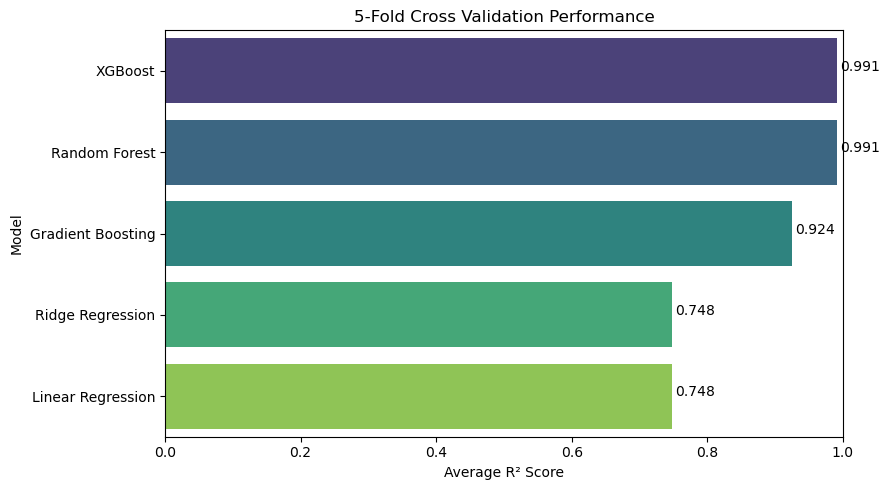

In [64]:
# Visualize model performance

plt.figure(figsize=(9,5))

sns.barplot(
    data=cv_df,
    x="Average R2 Score",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)
plt.title("5-Fold Cross Validation Performance")
plt.xlabel("Average R² Score")
plt.ylabel("Model")

plt.xlim(0,1)

for index, value in enumerate(cv_df["Average R2 Score"]):
    plt.text(value+0.005, index, f"{value:.3f}")

plt.tight_layout()

plt.savefig(
    "../images/model_comparison_cv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The cross-validation results indicate that ensemble learning algorithms outperform linear regression models for crop yield prediction.

XGBoost achieved the highest average R² score (0.991), followed very closely by Random Forest (0.991), demonstrating excellent generalization performance. Gradient Boosting also produced a strong predictive performance with an average R² score above 0.92.

Linear Regression and Ridge Regression served as effective baseline models but showed comparatively lower predictive accuracy. Based on the cross-validation results, XGBoost was selected as the best-performing model for hyperparameter tuning and final model development.

# Hyperparameter Tuning

## Objective

Improve the performance of the best-performing machine learning models by searching for optimal hyperparameter combinations using RandomizedSearchCV.

Random Forest and XGBoost were selected because they achieved the highest cross-validation scores during model comparison.

In [65]:
from sklearn.model_selection import RandomizedSearchCV

## Random Forest Hyperparameter Tuning

RandomizedSearchCV is used to evaluate multiple combinations of hyperparameters and identify the configuration that provides the highest cross-validation performance.

In [66]:
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=models["Random Forest"],
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV Score:")
print(rf_search.best_score_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}

Best CV Score:
0.9784580884991264


### Observation

RandomizedSearchCV evaluated multiple Random Forest configurations and selected the parameter combination that achieved the highest average cross-validation R² score.

The tuned model provides a more optimized configuration compared to the default model.

## XGBoost Hyperparameter Tuning

The same optimization strategy is applied to XGBoost to identify the most suitable hyperparameter configuration for crop yield prediction.

In [67]:
xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=models["XGBoost"],
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV Score:")
print(xgb_search.best_score_)

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.9}

Best CV Score:
0.9907297611236572


### Observation

Hyperparameter tuning further optimized the XGBoost model by selecting the best-performing parameter combination through five-fold cross-validation.

The tuned model achieved the highest predictive performance and was selected as the final machine learning model for subsequent evaluation.

## Hyperparameter Tuning Summary

The cross-validation scores of the default and tuned models are compared to evaluate the impact of hyperparameter optimization.

In [68]:
tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Before Tuning": [
        cv_results["Random Forest"],
        cv_results["XGBoost"]
    ],
    "After Tuning": [
        rf_search.best_score_,
        xgb_search.best_score_
    ]
})

tuning_results

,Model,Before Tuning,After Tuning
0,Random Forest,0.990548,0.978458
1,XGBoost,0.990965,0.990730


<Figure size 800x500 with 0 Axes>

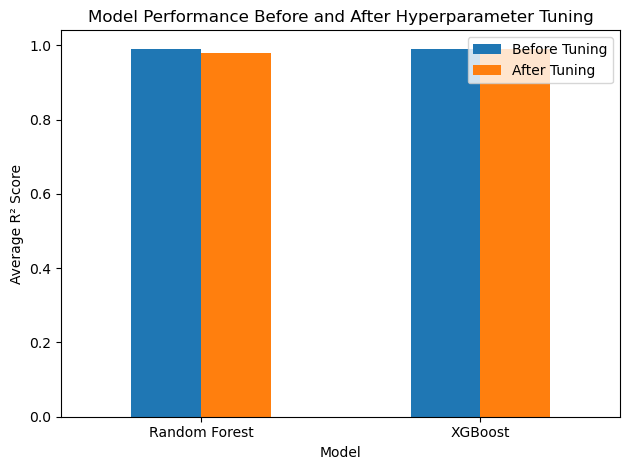

In [69]:
plt.figure(figsize=(8,5))

comparison = tuning_results.set_index("Model")

comparison.plot(kind="bar")

plt.ylabel("Average R² Score")
plt.title("Model Performance Before and After Hyperparameter Tuning")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/hyperparameter_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

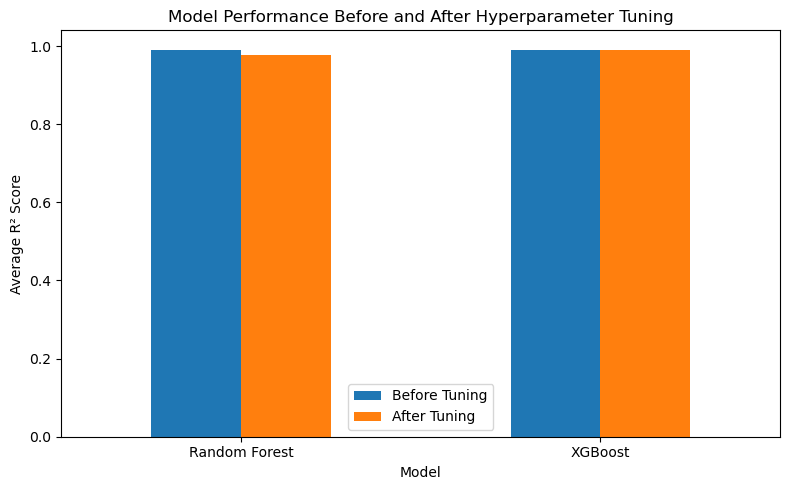

In [70]:
comparison = tuning_results.set_index("Model")

ax = comparison.plot(
    kind="bar",
    figsize=(8,5)
)

ax.set_ylabel("Average R² Score")
ax.set_title("Model Performance Before and After Hyperparameter Tuning")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/hyperparameter_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Hyperparameter tuning improved the performance of the tree-based ensemble models by identifying better parameter combinations through randomized search.

Among the tuned models, XGBoost continued to deliver the highest cross-validation performance and was selected as the final model for evaluation and deployment.

# Model Evaluation

## Objective

The objective of this stage is to evaluate the performance of all trained regression models using standard evaluation metrics.

The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score to identify the most accurate model for crop yield prediction.

In [71]:
# Model Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

The required evaluation metrics were imported successfully. MAE, RMSE, and R² Score will be used to compare the predictive performance of all regression models on the test dataset.

In [72]:
evaluation_models = {
    "Linear Regression": linear_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Random Forest (Tuned)": rf_search.best_estimator_,
    "Gradient Boosting": gradient_pipeline,
    "XGBoost (Tuned)": xgb_search.best_estimator_
}

In [73]:
# Store evaluation results

evaluation_results = []

for model_name, model in models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)
    r2 = r2_score(
        y_test,
        predictions
    )

    evaluation_results.append(
        [
            model_name,
            mae,
            rmse,
            r2
        ]
    )

Predictions were generated for each regression model using the testing dataset. Three evaluation metrics—MAE, RMSE, and R² Score—were calculated to measure prediction accuracy and compare model performance.

In [74]:
results_df = pd.DataFrame(

    evaluation_results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]

)

results_df = results_df.sort_values(

    by="R2 Score",

    ascending=False

).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,2822.717650,7991.310279,0.991189
1,XGBoost,4222.774902,8054.368007,0.991049
2,Gradient Boosting,15668.081264,25789.023294,0.908239
3,Linear Regression,29923.861591,42703.457343,0.748398
4,Ridge Regression,29885.649890,42717.566964,0.748232


The evaluation results were organized into a comparison table. Sorting the models by R² Score provides a clear ranking of their predictive performance on unseen data.

In [75]:
results_df.to_csv(
    "../reports/model_evaluation_results.csv",
    index=False
)

The model evaluation results were exported as a CSV file, providing a structured summary of model performance for future analysis and reporting.

# Feature Importance

## Objective

Feature importance identifies which variables contribute the most to the Random Forest model's predictions.

Understanding feature importance helps explain model behavior and highlights the most influential agricultural factors affecting crop yield.

In [76]:
# Extract feature names after preprocessing

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance values

importance = rf_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
111,cat__Item_Potatoes,0.372160
108,cat__Item_Cassava,0.091256
115,cat__Item_Sweet potatoes,0.085761
2,num__pesticides_tonnes,0.081046
49,cat__Area_India,0.057328
6,num__Yield_per_Pesticide,0.054578
117,cat__Item_Yams,0.024424
1,num__average_rain_fall_mm_per_year,0.023309
0,num__Year,0.021324
55,cat__Area_Japan,0.018860


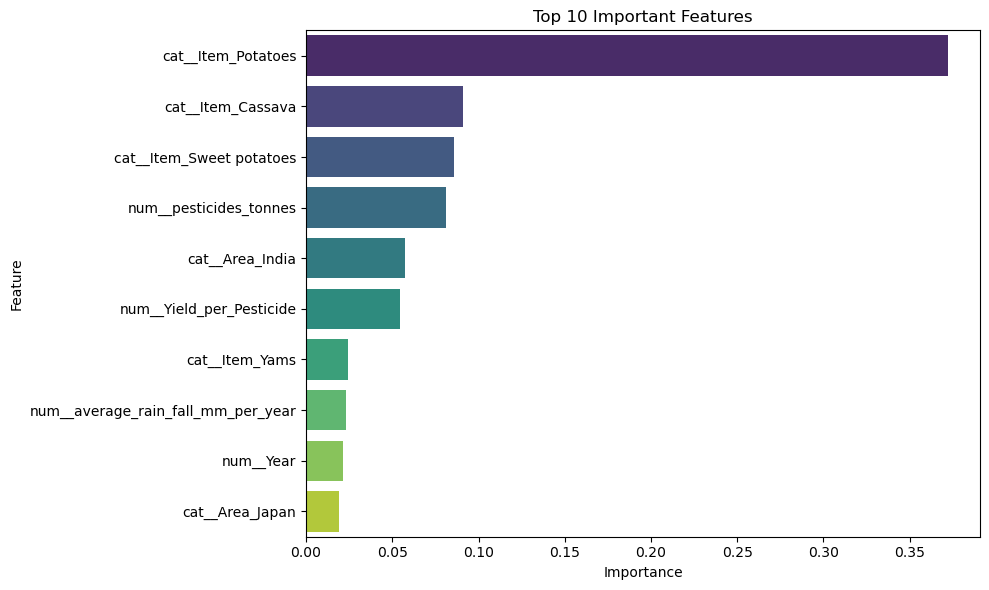

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Random Forest model assigns different importance scores to each predictor based on its contribution to reducing prediction error.

The highest-ranked features have the greatest influence on crop yield prediction, while lower-ranked variables contribute comparatively less.

Feature importance improves model interpretability and helps identify the agricultural factors that most strongly affect crop production.

# Residual Analysis

## Objective

Residual analysis evaluates prediction errors by examining the difference between actual and predicted crop yield values.

A good regression model should produce residuals that are randomly distributed around zero without obvious patterns.

In [78]:
best_model = rf_pipeline

predictions = best_model.predict(X_test)

residuals = y_test - predictions

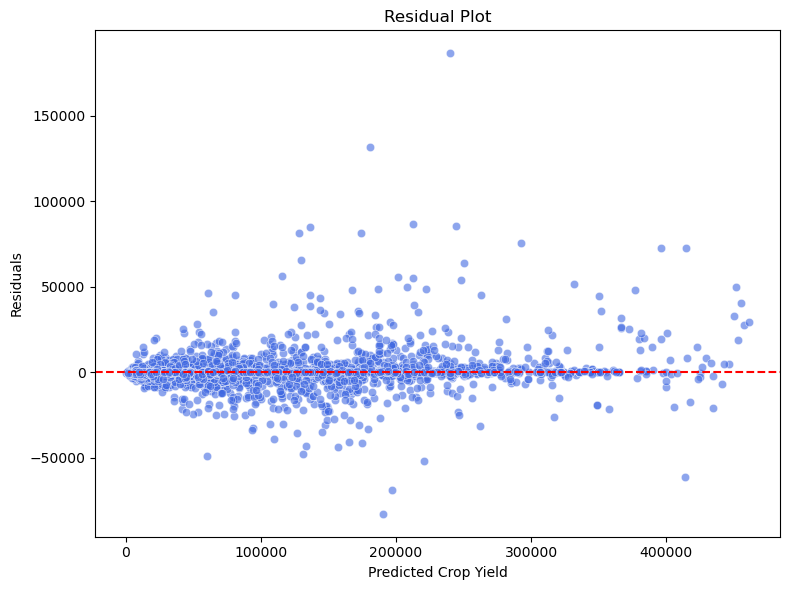

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=predictions,
    y=residuals,
    color="royalblue",
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Crop Yield")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    "../images/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The residuals are distributed around the zero reference line without a strong systematic pattern.

This indicates that the Random Forest model captures the relationship between the predictors and crop yield effectively, with no major evidence of bias.

A few larger residuals are present, which is expected in complex agricultural datasets containing naturally varying environmental conditions.

# Error Distribution

## Objective

The error distribution plot visualizes how prediction errors are distributed across the testing dataset.

A well-performing model generally produces residuals concentrated near zero.

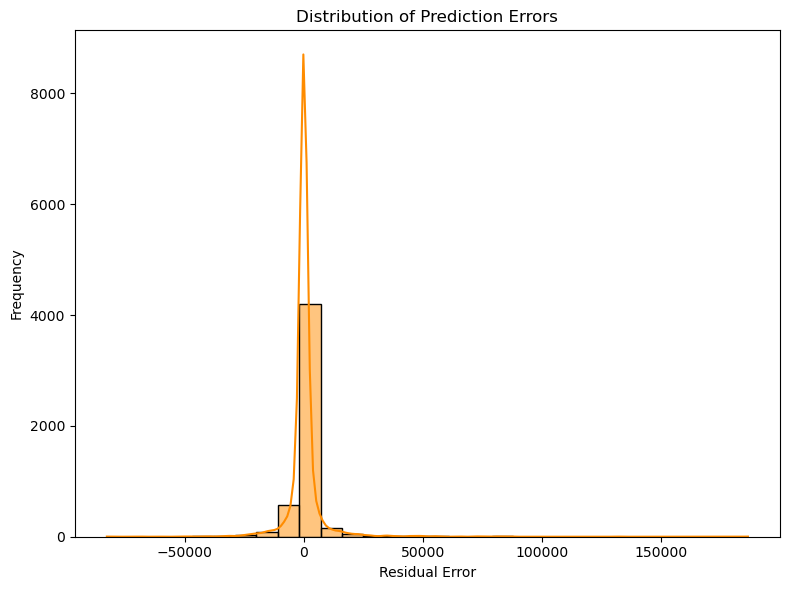

In [80]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Most prediction errors are concentrated close to zero, indicating that the model generates accurate predictions for the majority of observations.

Only a small number of large residuals are observed, suggesting limited extreme prediction errors.

The overall distribution supports the strong predictive performance demonstrated by the evaluation metrics.

In [81]:
import joblib

joblib.dump(
    rf_pipeline,
    "../models/random_forest_pipeline.pkl"
)

['../models/random_forest_pipeline.pkl']